In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# pd.set_option('display.notebook_repr_html', True)
pd.set_option('display.notebook_repr_html', False)

df_ratio = pd.read_csv('stacked_ratio.csv', encoding="CP949")
df_ratio.head()

  deviceId    부재  미활동    활동   주의  낙상
0      #01  2793  843   664   20   0
1      #02  3906  175   236    3   0
2      #03  2827  275  1042  174   2
3      #04  1046  613  2647   14   0
4      #05  1046  650  2606   17   1

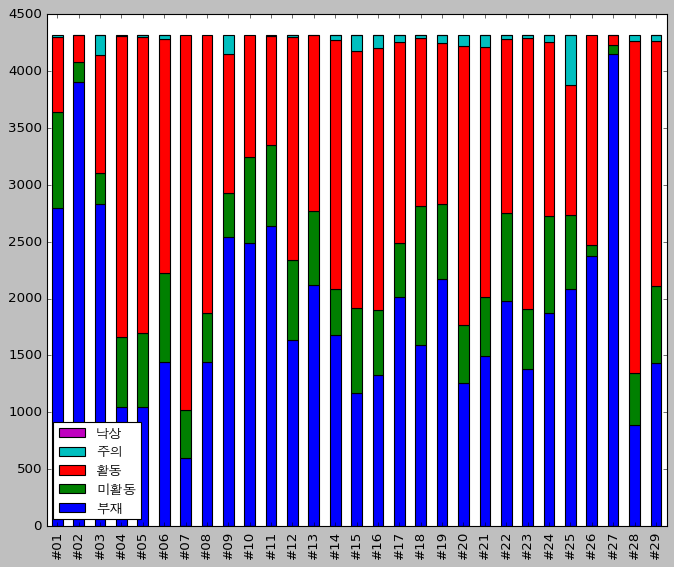

In [29]:
# plt.style.use('grayscale')
plt.style.use('classic')
# 한글 폰트 설정
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"  # Mac 기본 한글 폰트 경로
font_prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['figure.figsize'] = [10, 8]
ax = df_ratio.plot.bar(stacked=True)
ax.set_xticklabels(df_ratio['deviceId'])

handles, labels = ax.get_legend_handles_labels()
# reverse both handles and labels
ax.legend(reversed(handles), reversed(labels), loc='best', prop = font_prop)

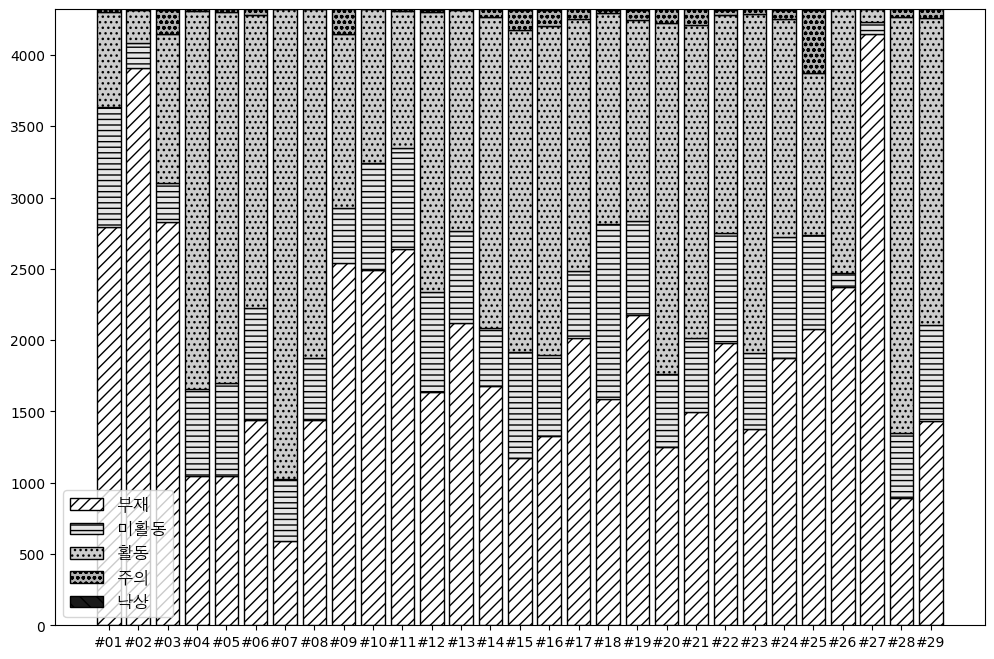

In [30]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 8]

deviceId = df_ratio['deviceId']
fall = df_ratio['낙상']
caution = df_ratio['주의']
action = df_ratio['활동']
non_action = df_ratio['미활동']
absent = df_ratio['부재']

plt.bar(deviceId, absent, edgecolor='black', color='w',
        hatch="///", label='부재')
plt.bar(deviceId, non_action, bottom=absent, edgecolor='black',
        color='0.9', hatch="---", label='미활동')
plt.bar(deviceId, action, bottom=absent+non_action,
        edgecolor='black', color='0.8', hatch="...", label='활동')
plt.bar(deviceId, caution, bottom=absent+non_action+action,
        edgecolor='black', color='0.7', hatch="ooo", label='주의')
plt.bar(deviceId, fall, bottom=absent+non_action+action+caution,
        edgecolor='black', color='0.1', hatch='\\\\', label='낙상')

plt.legend(loc='best', prop = font_prop)
plt.show()

### 부재는 0으로 처리하여 가시화

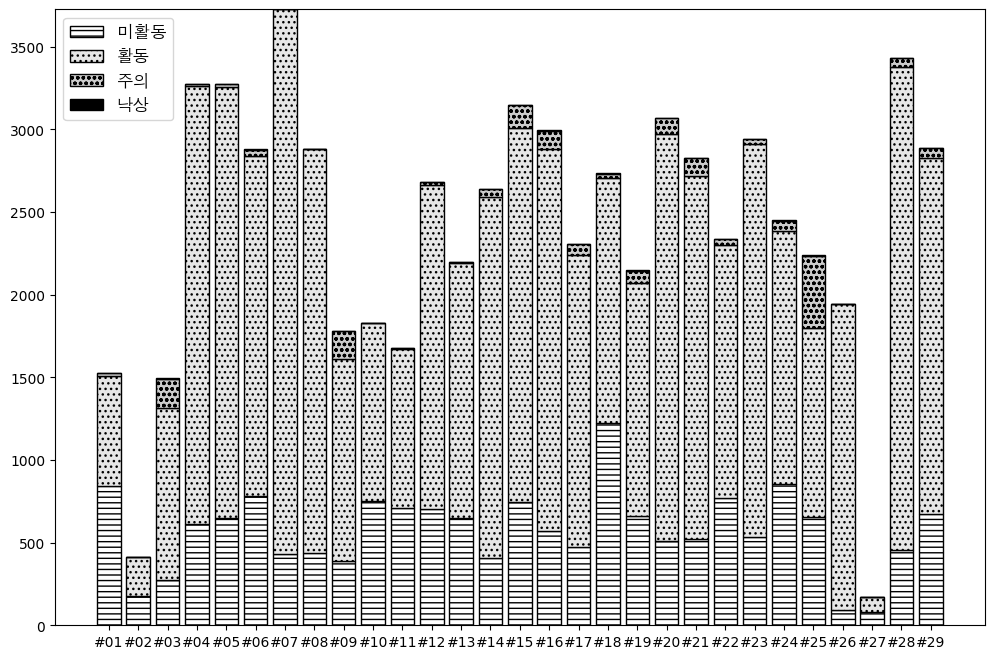

In [31]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 8]


df_not_absence = pd.read_csv('stacked_not_absence.csv', encoding="CP949")

deviceId = df_not_absence['deviceId']
fall = df_not_absence['낙상']
caution = df_not_absence['주의']
action = df_not_absence['활동']
non_action = df_not_absence['미활동']

plt.bar(deviceId, non_action, edgecolor='black',
        color='w', hatch="---", label='미활동')
plt.bar(deviceId, action, bottom=non_action,
        edgecolor='black', color='0.9', hatch="...", label='활동')
plt.bar(deviceId, caution, bottom=non_action+action,
        edgecolor='black', color='0.8', hatch="ooo", label='주의')
plt.bar(deviceId, fall, bottom=non_action+action+caution,
        edgecolor='black', color='0', hatch='\\\\', label='낙상')

plt.legend(loc='best', prop = font_prop)
plt.show()

### 센서#25 분석

In [ ]:
df_ratio = pd.read_csv('stacked_one_25.csv',
                       dtype={'day':object, '부재':int, '미활동':int,
                              '활동':int,'주의':int,'낙상':int},
                       encoding="CP949")
df_ratio.head()

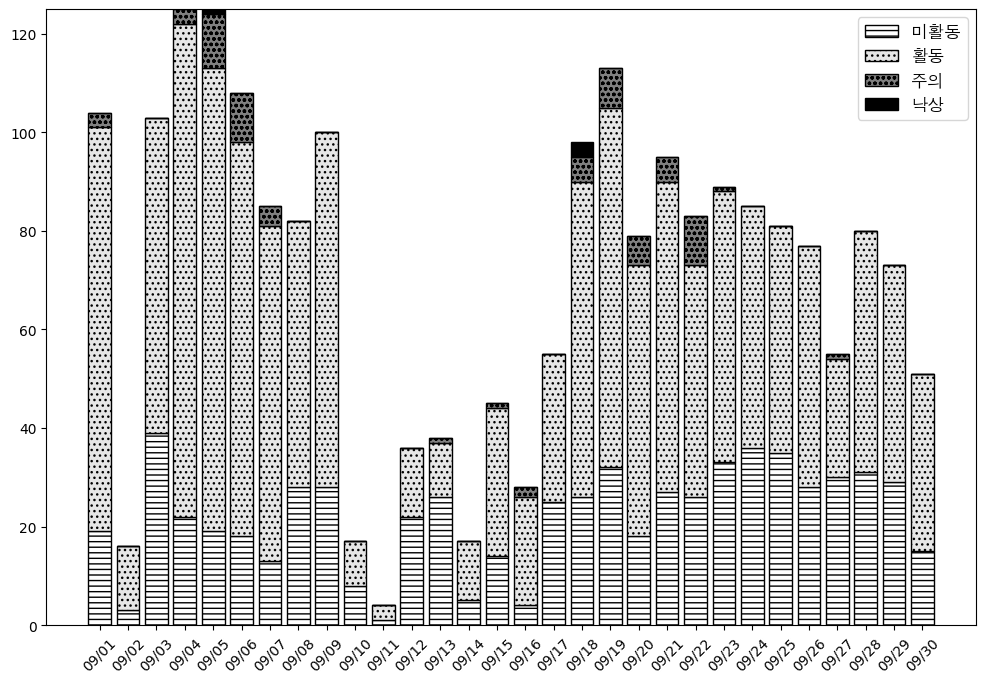

In [35]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 8]

day = df_ratio['day']
fall = df_ratio['낙상']
caution = df_ratio['주의']
action = df_ratio['활동']
non_action = df_ratio['미활동']

plt.bar(day, non_action, edgecolor='black',
        color='w', hatch="---", label='미활동')
plt.bar(day, action, bottom=non_action, edgecolor='black',
        color='0.9', hatch="...", label='활동')
plt.bar(day, caution, bottom=non_action+action, edgecolor='black',
        color='0.5', hatch="ooo", label='주의')
plt.bar(day, fall, bottom=non_action+action+caution,
        edgecolor='black', color='0', hatch='\\\\', label='낙상')

plt.legend(loc='best', prop=font_prop)
plt.xticks(rotation=45)
plt.show()

### 센서#19 분석

In [32]:
# 부재 정보를 포함해서 확인하기
df_ratio = pd.read_csv('stacked_one_19.csv',
                       dtype={'day':object, '부재':int, '미활동':int,
                              '활동':int,'주의':int,'낙상':int},
                       encoding="CP949")
df_ratio.head()

     day  부재  미활동   활동  주의  낙상
0  09/01   0   19   82   3   0
1  09/02   0    3   13   0   0
2  09/03   0   39   64   0   0
3  09/04   0   22  100   3   0
4  09/05   0   19   94  11   1

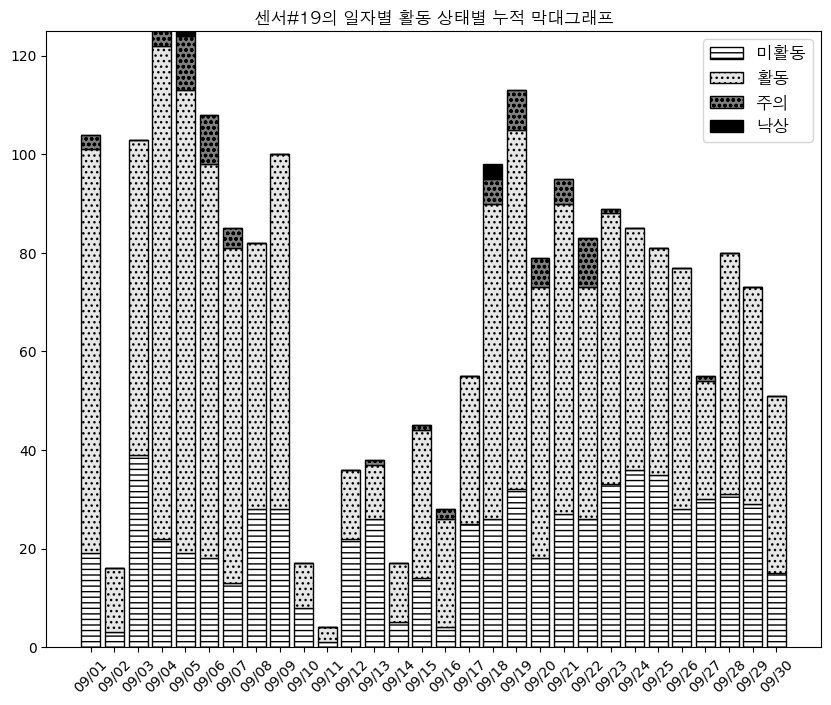

In [34]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = [10, 8]

day = df_ratio['day']
fall = df_ratio['낙상']
caution = df_ratio['주의']
action = df_ratio['활동']
non_action = df_ratio['미활동']

plt.bar(day, non_action, edgecolor='black',
        color='w', hatch="---", label='미활동')
plt.bar(day, action, bottom=non_action, edgecolor='black',
        color='0.9', hatch="...", label='활동')
plt.bar(day, caution, bottom=non_action+action, edgecolor='black',
        color='0.5', hatch="ooo", label='주의')
plt.bar(day, fall, bottom=non_action+action+caution,
        edgecolor='black', color='0', hatch='\\\\', label='낙상')

plt.legend(loc='best', prop=font_prop)
plt.title('센서#19의 일자별 활동 상태별 누적 막대그래프', fontproperties=font_prop)
plt.xticks(rotation=45)
plt.show()

### 📌 분석 결과

➡️ 센서#19는 센서#25에 비해 주의와 낙상이 적게 감지되었지만 9월 18일에 낙상이 여러 번 감지되었음   
➡️ 센서#25는 전체적으로 주의가 많이 감지되었음 (원인: 노약자들이 하반신이 불편해 바닥에 자주 앉음)

## 주의와 낙상의 scatter 분석

In [37]:
df_summary = pd.read_csv('fall_summary_cleaned.csv', encoding="CP949")
df_summary

    deviceId    mon  caution  fall
0        #01  23/01     35.0   1.0
1        #01  23/07    130.0   6.0
2        #01  23/08     94.0   3.0
3        #01  23/11     48.0   1.0
4        #01  23/12     54.0   1.0
..       ...    ...      ...   ...
282      #41  23/08    754.0  18.0
283      #41  23/09    218.0   1.0
284      #41  23/10     86.0   0.0
285      #41  23/11     30.0   0.0
286      #41  23/12     47.0   2.0

[287 rows x 4 columns]

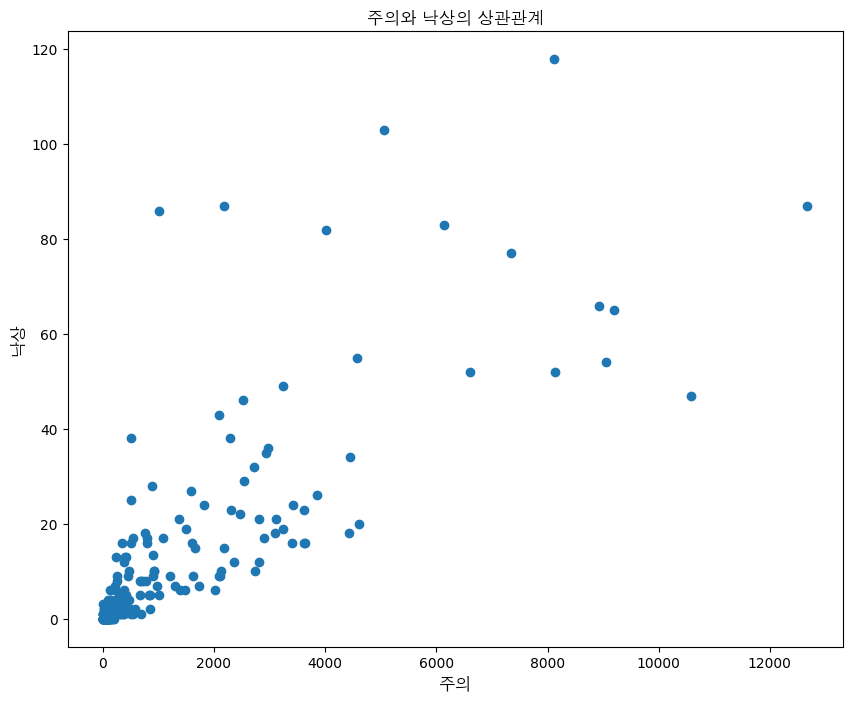

In [38]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1,1,1)
ax.scatter(df_summary['caution'], df_summary['fall'])
ax.set_xlabel('주의', fontproperties = font_prop)
ax.set_ylabel('낙상', fontproperties = font_prop)

plt.title('주의와 낙상의 상관관계', fontproperties = font_prop)
plt.show()

### 📌 분석 결과

➡️ 주의가 많이 감지될 수록 낙상도 많이 감지되었음  

## 주의와 낙상의 회귀분석

In [39]:
# 주의, 낙상 값 추출
X = df_summary.caution.values
Y = df_summary.fall.values

# X, Y를 2d array로 변경
X = X.reshape(-1,1)
Y = Y.reshape(-1,1)

In [ ]:
# 회귀분석하기
from sklearn.linear_model import LinearRegression  # 선형회귀모델
lr = LinearRegression()

lr.fit(X, Y)  # 학습

# r 계수
print (lr.coef_[0])  # 기울기

# y 절편
print (lr.intercept_)

[0.0080895]
[1.80248273]


-> 계산 방법   
0.0080895 * 50 (회) + 1.80248273 = 2.20695773   
: 주의가 50회 발생한 경우, 낙상은 2.2회 발생할 것으로 예측할 수 있음

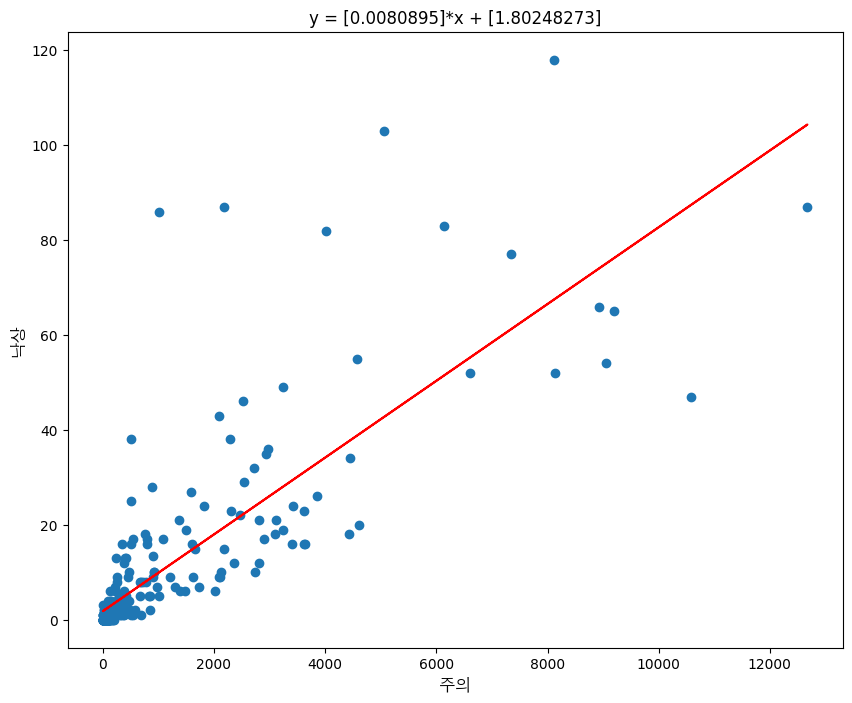

In [41]:
NewY = lr.coef_[0]*X +lr.intercept_

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1,1,1)
ax.scatter(X, Y)
ax.set_xlabel('주의', fontproperties = font_prop)
ax.set_ylabel('낙상', fontproperties = font_prop)

plt.plot(X, NewY, color='red')
plt.title('y = {}*x + {}'.format(lr.coef_[0], lr.intercept_))
plt.show()

In [42]:
#pip install statsmodels
import statsmodels.api as sm
pd.set_option('display.notebook_repr_html', False)

res = sm.OLS(Y, sm.add_constant(X)).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     559.0
Date:                Tue, 18 Mar 2025   Prob (F-statistic):           3.75e-69
Time:                        10:16:01   Log-Likelihood:                -1085.0
No. Observations:                 287   AIC:                             2174.
Df Residuals:                     285   BIC:                             2181.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8025      0.700      2.575      0.011       0.425       3.180
x1             0.0081      0.000     23.643      0.000       0.007       0.009
==============================================================================
Omnibus:                      254.970   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5762.432
Skew:                           3.562   Prob(JB):                         0.00
Kurtosis:                      23.764   Cond. No.                     2.28e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.28e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

R-squared만 1에 가까울 수록 좋은 모델! 나머지는 다 작아야 좋음